In [1]:

 
import numpy as np
import astropy.units as u
from scipy import ndimage
from astropy.io import fits
from astropy.convolution import Gaussian2DKernel, Gaussian1DKernel
from spectral_cube import SpectralCube, BooleanArrayMask


"""
co_prior_3d_masking.py — 当前目标：CS 2-1（亮环 + 环内弱弥漫，走弱线自掩方案）

用 CO 2-1 亮线 cube 生成高信噪比 3D mask（hierarchical / "dilated" mask），
再投影到目标 cube 上计算 Moment 0，并与参考图
M95_C5+C2_hcn10_prior_moment0.png 的 cs21 面板（上排中间）对比。

改进要点（相对 01 Spatial Smoothing.ipynb）：
1. mask 由 CO 2-1 生成，reproject 到目标 cube 网格（空间+谱轴），而不是每个 cube 自掩码。
2. 3D 平滑：空间 + 谱向同时平滑（原来只有空间平滑）。
3. 噪声用 line-free 通道逐通道估计（原来是整个 cube 一个标量，含信号污染）。
4. 双阈值区域生长：core >= 4σ 向 low >= 2σ 生长（原来单层 3σ，弱延展发射被切碎）。
5. 速度相干性 + 最小尺寸过滤：去除跨 <2 通道或 <1 beam 面积的噪声岛。
6. moment 0 在目标 cube 原始网格、原始分辨率上计算；reproject 只用于最后的对比图。

数据：
  CO 2-1 : 431x418x275, 0.4"/pix, beam 1.46" (~3.7 pix), 通道 2.54 km/s
  HCN 1-0: 360x360x61,  0.1"/pix, beam 0.91" (~9.1 pix), 通道 9.91 km/s（亮线方案）
  CS 7-6 : 360x360x64,  0.1"/pix, beam 0.72" (~7.2 pix), 通道 9.40 km/s（弱线方案）
  CO 3-2 : 360x360x709, 0.1"/pix, beam 0.57" (~5.7 pix), 通道 0.847 km/s,
           v=478-1078 km/s，native 逐通道 rms ~0.20 K。
           亮线（积分谱峰 ~9800，参考图 co32 与 hcn10 同为亮环形态），
           采用 weak_line=False 纯 CO 2-1 先验；线速度范围 ~625-918 km/s。
  HCO+4-3: 360x360x51, 0.1"/pix, beam 0.70" (~7.0 pix), 通道 9.85 km/s,
           v=539-1032 km/s（谱轴递减），native 逐通道 rms ~0.042 K。
           弱线（全局谱被旋转摊薄，发射为沿环离散亮团，参考图 hcop43 色标仅 1-4），
           采用 weak_line=True 的 CO 先验∩峰锚定连通自掩；线窗 625-918（ch12-41），
           line-free 为 ch0:11 + ch43:51。环内（CO 环形态学 envelope）弥漫弱发射
           在 1σ 阈+nchan>=2 下被整片剪掉，故环内 low 降为 0.75σ、环外维持 1σ。
  CS 2-1 : 360x360x67, 0.1"/pix, beam 0.85" (~8.5 pix), 通道 8.97 km/s,
           v=481-1073 km/s（谱轴递减），native 逐通道 rms ~0.10 K。
           积分谱峰虽亮（亮环，参考 cs21 色标 5-15），但逐像素单通道仅 1-2σ，
           环内为弥漫弱发射（参考图亮环+紫雾内环）。纯 CO prior 会过掩（空间
           覆盖 43%、掩内中位 |S/N| 仅 0.9、外围噪声斑块），故采用 weak_line=True
           峰锚定自掩：平滑 8 pix/2ch，core 3σ/low 1σ，环 envelope 内 low=0.5σ
           （环内弱弥漫比 hcop43 更低，0.75σ 仍剪黑环带内缘）；线窗 625-918
           （ch18-49），line-free 为 ch0:17 + ch50:66（ch66 整通道全 NaN，
           不参与 line-free，PB 有效区只按有效通道聚合）。
           最终 2D footprint 再向里腐蚀 3 pix（0.3"）剥掉最外围一圈
           锯齿状弱边。
"""

In [2]:
# ---------------------------------------------------------------------------
# 噪声估计
# ---------------------------------------------------------------------------
def estimate_noise_per_channel(cube, line_free_channels):
    """用 line-free 通道的 MAD 估计逐通道噪声 (与 cube 同单位)。

    Parameters
    ----------
    cube : SpectralCube
    line_free_channels : array of int
        没有线发射的通道序号（先画一条 integrated spectrum 人工确认）。

    Returns
    -------
    noise : Quantity, shape (nchan,)
    """
    data = cube.filled_data[:].value          # NaN 已填充
    noise = np.full(cube.shape[0], np.nan)
    for i in line_free_channels:
        plane = data[i][np.isfinite(data[i])]
        noise[i] = 1.4826 * np.median(np.abs(plane - np.median(plane)))
    # 线性插值到所有通道（噪声随通道变化平缓）
    good = np.isfinite(noise)
    noise = np.interp(np.arange(cube.shape[0]), np.where(good)[0], noise[good])
    return noise * cube.unit



In [3]:
# ---------------------------------------------------------------------------
# 3D 平滑
# ---------------------------------------------------------------------------
def smooth_3d(cube, spatial_fwhm_pix, spectral_fwhm_chan):
    """空间 + 谱向高斯平滑。平滑核宽度应 ~beam / ~线宽，而不是固定 5 pixel。"""
    k_sp = Gaussian2DKernel(spatial_fwhm_pix / 2.3548)
    k_v  = Gaussian1DKernel(spectral_fwhm_chan / 2.3548)
    return cube.spatial_smooth(k_sp).spectral_smooth(k_v)



In [4]:
# ---------------------------------------------------------------------------
# 双阈值区域生长 mask（Rosolowsky & Leroy 2006 / PHANGS-ALMA 风格）
# ---------------------------------------------------------------------------
def hierarchical_mask(cube, noise, core_sigma=4.0, low_sigma=2.0,
                      min_channels=2, min_pixels=None, bound=None):
    """在 *平滑后* 的 cube 上生成 3D mask。

    core: >= core_sigma 的体素作为种子
    grow: 生长到 >= low_sigma 的连通体素
    过滤: 保留跨越 >= min_channels 个通道且 >= min_pixels 个像素的区域
    bound: 可选布尔数组，区域生长被限制在该先验边界内
           （弱线时传入 CO prior，mask = CO 先验 ∩ 目标线自检测）
    """
    data = cube.filled_data[:].value
    noise_arr = noise.to(cube.unit).value[:, None, None]   # 逐通道广播

    snr = data / noise_arr
    core = snr >= core_sigma
    low  = snr >= low_sigma
    if bound is not None:
        core &= bound
        low  &= bound

    # 区域生长：从 core 出发，在 low 内做连通性传播（3D，26 邻域）
    struct = ndimage.generate_binary_structure(3, 3)
    grown = ndimage.binary_propagation(core, mask=low, structure=struct)

    # 过滤：速度相干性（跨 >= min_channels 个通道）+ 最小区域尺寸
    lab, n = ndimage.label(grown, structure=struct)
    if min_pixels is None:
        min_pixels = 1
    counts = np.bincount(lab.ravel())
    spec_span = np.zeros(n + 1, dtype=int)
    for s in range(cube.shape[0]):
        ids = np.unique(lab[s][lab[s] > 0])
        spec_span[ids] += 1
    ok = (counts >= min_pixels) & (spec_span >= min_channels)
    ok[0] = False
    keep = ok[lab]
    return keep




In [5]:
def beam_area_pixels(cube):
    """beam 面积（像素数），作为 min_pixels 的物理下限。"""
    from radio_beam import Beam
    beam = Beam.from_fits_header(cube.header)
    pix = abs(cube.header['CDELT1']) * u.deg
    return int(np.ceil((beam.sr / (pix**2).to(u.sr)).value))


In [6]:
# ---------------------------------------------------------------------------
# mask 从 CO 投影到目标 cube（HCN / CS）
# ---------------------------------------------------------------------------
def transfer_mask(mask_bool, co_cube, tgt_cube):
    """把 CO 网格上的布尔 mask 重采样到目标 cube 网格。

    不用 SpectralCube.reproject：两条谱轴 RESTFRQ 不同（230.5 vs 88.6/342.9 GHz），
    经频率换算世界坐标时会错位导致全 NaN。也不依赖 reproject 包，改为：
      1) 谱向按速度值 (km/s) 用 numpy 线性插值（CO 谱轴递减，先排序）；
      2) 空间逐通道用 astropy WCS（自动处理 FK5/ICRS）+ scipy 双线性插值。
    CO beam (1.46") 比目标 beam 大，mask 天然偏保守。
    """
    from astropy.coordinates import SkyCoord
    from scipy.ndimage import map_coordinates

    v_co  = co_cube.spectral_axis.to(u.km / u.s).value
    v_t   = tgt_cube.spectral_axis.to(u.km / u.s).value
    m = mask_bool.astype(np.float32)

    # --- 谱向重采样 ---
    order = np.argsort(v_co)                       # CO 速度轴递减 -> 升序
    v_sorted, m_sorted = v_co[order], m[order]
    idx = np.interp(v_t, v_sorted, np.arange(len(v_sorted)),
                    left=-1, right=-1)             # CO 覆盖范围外 -> -1
    spec_resampled = np.zeros((len(v_t),) + m.shape[1:], dtype=np.float32)
    for j, fi in enumerate(idx):
        if fi < 0:
            continue
        i0 = int(np.floor(fi))
        i1 = min(i0 + 1, len(v_sorted) - 1)
        w = fi - i0
        spec_resampled[j] = (1 - w) * m_sorted[i0] + w * m_sorted[i1]

    # --- 空间逐通道重投影: 目标像素 -> 天球(含 FK5/ICRS 转换) -> CO 像素 ---
    ny, nx = tgt_cube.shape[1:]
    yy, xx = np.mgrid[0:ny, 0:nx]
    sc = tgt_cube.wcs.celestial.pixel_to_world(xx.ravel(), yy.ravel())
    frame = co_cube.wcs.celestial.wcs.radesys
    if isinstance(frame, bytes):
        frame = frame.decode()
    frame = {'ICRS': 'icrs', 'FK5': 'fk5', 'FK4': 'fk4'}.get(
        str(frame).strip(), 'icrs')
    co_sc = sc.transform_to(frame)
    cx, cy = co_cube.wcs.celestial.world_to_pixel(co_sc)
    coords = np.vstack([cy.reshape(1, -1), cx.reshape(1, -1)])

    out = np.zeros((len(v_t), ny, nx), dtype=np.float32)
    for j in range(len(v_t)):
        p = map_coordinates(spec_resampled[j], coords, order=1,
                            mode='constant', cval=0.0)
        out[j] = p.reshape(ny, nx)
    return out >= 0.5                              # 插值后再阈值化





In [7]:
import os
for f in ['ngc3351_12m+7m+tp_co21.fits',
          'M95_C5+C2_hcn10_pbcorr_round_k.fits',
          'M95_C3+7m_cs76_pbcorr_round_k.fits',
          'M95_C3+7m_co32_pbcorr_round_k.fits',
          'M95_C3+7m_hcop43_pbcorr_round_k.fits',
          'M95_C5+C2_cs21_pbcorr_round_k.fits']:
    print(f, '存在' if os.path.exists(f) else '缺失!')


ngc3351_12m+7m+tp_co21.fits 存在
M95_C5+C2_hcn10_pbcorr_round_k.fits 存在
M95_C3+7m_cs76_pbcorr_round_k.fits 存在
M95_C3+7m_co32_pbcorr_round_k.fits 缺失!
M95_C3+7m_hcop43_pbcorr_round_k.fits 缺失!
M95_C5+C2_cs21_pbcorr_round_k.fits 存在


In [8]:
refil = '../ngc3351_12m+7m+tp_co21.fits'   # CO 2-1 cube 在上一级根目录
#spefi_ = 'M95_C5+C2_hcn10_pbcorr_round_k.fits'
#spefi_ = 'M95_C3+7m_cs76_pbcorr_round_k.fits'
#spefi_ = 'M95_C3+7m_co32_pbcorr_round_k.fits'
#spefi_ = 'M95_C3+7m_hcop43_pbcorr_round_k.fits'
spefi_ = 'M95_C5+C2_cs21_pbcorr_round_k.fits'

#outmomt = 'M95_C5+C2_hcn10_co_prior_mom0.fits'
#outmomt = 'M95_C5+C2_cs76_co_prior_mom0.fits'
#outmomt = 'M95_C3+7m_co32_co_prior_mom0.fits'
#outmomt = 'M95_C3+7m_hcop43_co_prior_mom0.fits'
outmomt = 'M95_C5+C2_cs21_co_prior_mom0.fits'

#outmask = 'co_mask_on_hcn_grid.fits'
#outmask = 'co_mask_on_cs76_grid.fits'
#outmask = 'co_mask_on_co32_grid.fits'
#outmask = 'co_mask_on_hcop43_grid.fits'
outmask = 'co_mask_on_cs21_grid.fits'


In [9]:
# 数据与 notebook 同目录；Mac 上如需绝对路径自行改这里
workdir = '.'
spefi = SpectralCube.read(f'{workdir}/{spefi_}')
spefi = spefi.with_spectral_unit(u.km / u.s)
print('spefi.header[BMAJ]=', spefi.header['BMAJ'])
print('spefi.header[CDELT1]=', spefi.header['CDELT1'])
spatial_fwhm_pix = spefi.header['BMAJ'] / np.abs(spefi.header['CDELT1'])
print('spatial_fwhm_pix =', spatial_fwhm_pix)
print('谱轴单位 =', spefi.spectral_axis.unit,
      ' 通道宽度 km/s =', abs(np.gradient(spefi.spectral_axis.value))[0])
spefi


spefi.header[BMAJ]= 0.00023608504045
spefi.header[CDELT1]= -2.777777777778e-05
spatial_fwhm_pix = 8.499061456199321
谱轴单位 = km / s  通道宽度 km/s = 8.966658390008888


SpectralCube with shape=(67, 360, 360) and unit=K:
 n_x:    360  type_x: RA---SIN  unit_x: deg    range:   160.985468 deg:  160.995652 deg
 n_y:    360  type_y: DEC--SIN  unit_y: deg    range:    11.698694 deg:   11.708667 deg
 n_s:     67  type_s: VRAD      unit_s: km / s  range:      480.989 km / s:    1072.788 km / s

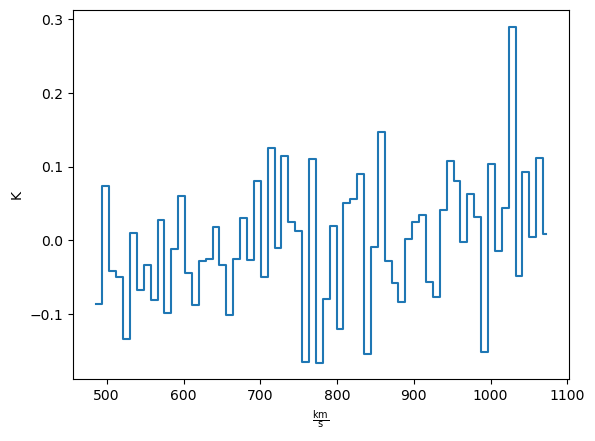

In [10]:
spefi[:,180,248].quicklook()

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# 读取速度轴（with_spectral_unit 之后单位是 km/s）
vel = spefi.spectral_axis.value
all_ch = np.arange(len(vel))

# 定义发射线速度范围 [km/s]（各线发射均落在 CO 环速度内，统一取 625-918）
v_line_min = 625.0
v_line_max = 918.0

# 判断哪些通道落在发射线区间
is_line_channel = (vel >= v_line_min) & (vel <= v_line_max)

# line-free通道：取反，不在发射速度区间的通道
line_free_channels = all_ch[~is_line_channel]

# 打印信息，核对
print(f"总通道数: {len(all_ch)}")
print(f"含发射线通道数量: {np.sum(is_line_channel)}")
print(f"line-free通道数量: {len(line_free_channels)}")
print(f"发射线对应的通道索引范围：{all_ch[is_line_channel][0]} ~ {all_ch[is_line_channel][-1]}")


总通道数: 67
含发射线通道数量: 32
line-free通道数量: 35
发射线对应的通道索引范围：18 ~ 49


In [12]:
import numpy as np

# 1. 获取光谱轴速度（km/s）
vel = spefi.spectral_axis.value
all_ch = np.arange(len(vel))

# 2. 发射线速度上下限 [km/s]
v_line_min = 625.0
v_line_max = 918.0

# 布尔数组：True=该通道在发射速度区间内（含发射线通道）
is_line_ch = (vel >= v_line_min) & (vel <= v_line_max)

# 提取所有含发射线通道索引
line_channels = all_ch[is_line_ch]

# 得到【第一个含发射通道】、【最后一个含发射通道】
ch_start = line_channels[0]
ch_end   = line_channels[-1]

print(f"含发射线通道范围：ch {ch_start} ~ ch {ch_end}")
print(f"对应速度：{vel[ch_start]:.2f} ~ {vel[ch_end]:.2f} km/s")


含发射线通道范围：ch 18 ~ ch 49
对应速度：911.39 ~ 633.42 km/s


外围腐蚀: 33,384 -> 24,629 像素 (剥除 8,755, 填回内洞 590)


CO  mask 体素: 706,101
投影到目标网格: 563,971 (6.5% of cube)
低阈连通块总数: 31, 含峰锚定块: 1
环 envelope 像素: 25,447（其内 low=0.5sigma）
最终 mask: 183,922 体素, 空间覆盖 19.0%
mom0 peak = 38.52 K km/s   (1-beam 平滑显示产品 peak = 26.21)
掩内 mom0 |S/N| 中位 = 2.68
|S/N|>3 像素占 FOV: 7.25%


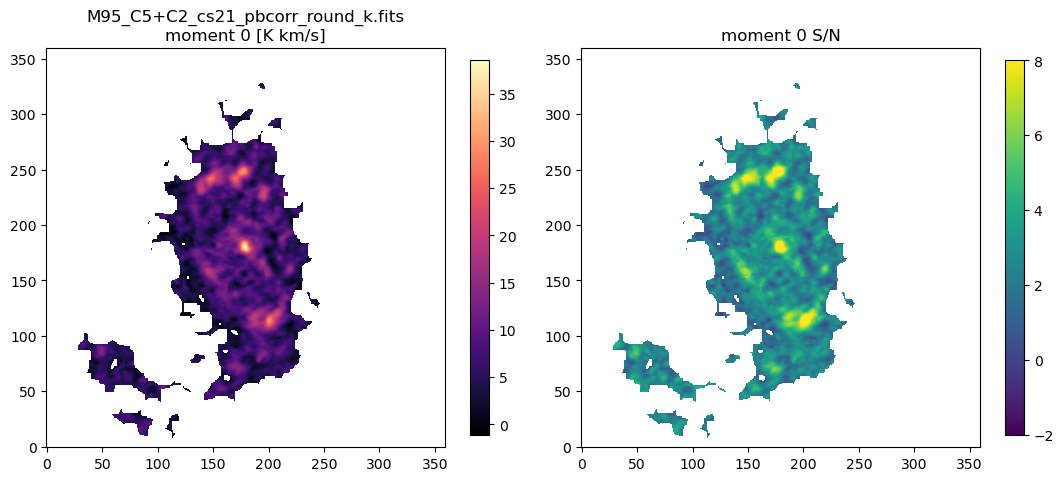

In [13]:
# ---------------------------------------------------------------------------
# 主流程
#   weak_line=True  -> 弱线 (CS 7-6 / HCO+ 4-3 / CS 2-1): CO 先验(空间 bound) ∩ 目标线“峰锚定连通”自掩
#   weak_line=False -> 亮线 (HCN 1-0 / CO 3-2): 纯 CO prior（HCN 已验证效果好；
#                      CO 3-2 同为亮环亮线，参考图形态与 HCN 一致，采用同一方案）
#
# 弱线形态模型：不再在局域峰上画离散圆盘（圆盘选不中峰间鞍部，会剪断 filament，
# 也留不住与亮环相连的南北暗弱尾）。改为在 ~1 beam 平滑 cube 上取 core(峰,3σ) 与
# low(低阈支撑) 两个掩膜，把 low 投影到天球做 8 邻域连通，只保留“含 core 峰”
# 的连通块——与峰相连的暗弱鞍部桥/细丝/南北尾作为同一块整体保留，不与任何峰相连
# 的孤立低阈噪声块整块剔除；3D 上仍逐通道取 low 以保谱线细节。
# ---------------------------------------------------------------------------
def main(weak_line=False):
    from scipy import ndimage
    workdir = '.'
    co    = SpectralCube.read(f'{workdir}/{refil}').with_spectral_unit(u.km / u.s)
    spefi = SpectralCube.read(f'{workdir}/{spefi_}').with_spectral_unit(u.km / u.s)

    # 目标 cube 一个束宽对应的像素数（显示用平滑核 / 核对参数）
    beam_pix_t = spefi.header['BMAJ'] / np.abs(spefi.header['CDELT1'])

    # --- 1. line-free 通道（在平滑 cube 上估噪声用）---
    co_line_free    = np.r_[0:84, 199:275]
    # CS 7-6 (64 ch, dv=9.4): np.r_[0:11, 45:64]
    # CO 3-2 (709 ch, dv=0.847): np.r_[0:140, 530:709]
    # HCO+ 4-3 (51 ch, dv=9.85, v 轴递减): v>923 -> ch 0:11；v<608 -> ch 43:51
    # CS 2-1  (67 ch, dv=8.97, v 轴递减): v>918 -> ch 0:17；v<625 -> ch 50:66
    #   ch66 (481 km/s) 整通道全 NaN，不放进 line-free；ch0/ch65 有效，MAD 插值仍可用
    tgt_line_free   = np.r_[0:17, 50:66]

    # --- 2. CO 先验 mask（亮线，收紧到 6σ/4σ，避免低阈支撑在外围渗流；
    #        HCN/CS/CO32 通用）：作为空间 bound ---
    co_s = smooth_3d(co, spatial_fwhm_pix=8, spectral_fwhm_chan=4)
    noise_co = estimate_noise_per_channel(co_s, co_line_free)
    mask_co = hierarchical_mask(co_s, noise_co,
                                core_sigma=6.0, low_sigma=4.0,
                                min_channels=2, min_pixels=beam_area_pixels(co))
    mask_prior = transfer_mask(mask_co, co_s, spefi)

    # 发射线速度窗（km/s），掩掉线外通道，防止先验在 line-free 区泄漏。
    # CO 2-1 自身发射覆盖 ~614-921 km/s，足以包住 CO 3-2 全线（~630-916）。
    vel = spefi.spectral_axis.value
    vwin = (vel >= 625.0) & (vel <= 918.0)
    mask_prior &= vwin[:, None, None]

    if weak_line:
        # CS 7-6 / HCO+ 4-3 / CS 2-1 单通道亮温均仅 1-2σ（native rms 0.036 /
        # 0.042 / 0.10 K）。平滑只取 ~1 beam + 2 通道：发射为束宽尺度团块；
        # 实测 2 beam 重平滑会摊薄信号（hcop43 中位 S/N 2.6 -> 1.7）。
        # hcop43 用 7 pix（beam 6.98）；cs21 beam=8.50 pix，用 8 pix。
        tgt_s = smooth_3d(spefi, spatial_fwhm_pix=8, spectral_fwhm_chan=2)
        noise_tgt = estimate_noise_per_channel(tgt_s, tgt_line_free)
        snr_t = tgt_s.filled_data[:].value / noise_tgt.value[:, None, None]

        # 1) core(峰) / low(低阈支撑) 两个 3D 掩膜，都限制在 CO 先验 + 速度窗内
        core_sigma, low_sigma, low_sigma_in = 3.0, 1.0, 0.5
        core3d = (snr_t >= core_sigma) & mask_prior

        # 1b) 环内降阈：HCO+4-3 / CS2-1 环内弥漫弱发射在 1sigma+nchan>=2 下被
        #     整片剪掉（hcop43 环内 1/3 像素丢失），而参考图环内是网状暗紫弱发射。
        #     用 CO 先验 2D 支撑做形态学闭合+填洞得到“环 envelope”（即环所围区域），
        #     envelope 内 low 降阈、环外维持 1sigma（避免低阈噪声沿旋臂渗流），
        #     r<95 裁切防止南北旋臂远段被并入 envelope。
        #     hcop43 用 0.75sigma；cs21 环内弥漫更暗，0.75sigma 仍剪黑环带内缘
        #     （环带覆盖 58%），0.5sigma 提到 66% 且不引入外围渗流，故取 0.5。
        co2d_any = mask_prior.any(axis=0)
        _closed = ndimage.binary_closing(co2d_any,
                                          structure=np.ones((25, 25)))
        inner_env = ndimage.binary_fill_holes(_closed)
        _nyi, _nxi = inner_env.shape
        _yyi, _xxi = np.mgrid[0:_nyi, 0:_nxi]
        inner_env &= np.hypot(_yyi - (_nyi - 1) / 2.0,
                               _xxi - (_nxi - 1) / 2.0) < 95.0
        low3d = (((snr_t >= low_sigma) |
                  ((snr_t >= low_sigma_in) & inner_env[None, :, :]))
                 & mask_prior)

        # 2) 峰锚点：core 在 >=2 个通道出现的空间像素（去单通道毛刺）
        seed2d = core3d.sum(axis=0) >= 2

        # 3) low 支撑投影到天球，8 邻域连通，只保留“含峰”的连通块。
        #    鞍部 filament / 南北尾只要在 low 阈上连续，就与峰属于同一块而整体保留；
        #    外围孤立低阈块因不含峰被整块剔除（这是外围干净的关键）。
        supp2d = low3d.any(axis=0)
        st2 = ndimage.generate_binary_structure(2, 2)
        lab, nlab = ndimage.label(supp2d, structure=st2)
        anchored_ids = np.unique(lab[seed2d & (lab > 0)])
        footprint = np.isin(lab, anchored_ids) & (lab > 0)

        # 4) 3D 逐通道取 low，空间只留峰连通域；再要求 >=2 通道（min_channels）
        mask_final = low3d & footprint[None, :, :]
        nchan = mask_final.sum(axis=0)
        mask_final = mask_final & (nchan >= 2)[None, :, :]

        # 5) 剥掉最外围一圈弱发射：最终 2D footprint 向里腐蚀 3 pix
        #    （0.1"/pix -> 0.3"，约 1/3 beam）。低阈自掩外缘呈锯齿状紫雾弱边
        #    （参考 cs21 面板外缘收得更紧），均匀剥一圈只去边缘低 S/N 碎边，
        #    不动主体；实测 5 pix 会切掉真实结构，1 pix 几乎无效。
        _fp_edge = mask_final.any(axis=0)
        _n_erode = 3
        _fp_eroded = ndimage.binary_erosion(
            _fp_edge, structure=st2, iterations=_n_erode)
        # 腐蚀会把 <6 pix 宽的窄湾/细腰蚀断并在内部封口成洞（西侧环内缘、
        # SW 臂上出现规则白穴）。只剥外缘：把“原本在 footprint 内、被腐蚀
        # 新封出的内洞”填回；原本就空的内洞保持不掩。
        _new_holes = ndimage.binary_fill_holes(_fp_eroded) & ~_fp_eroded
        _fp_eroded = _fp_eroded | (_new_holes & _fp_edge)
        print(f'外围腐蚀: {_fp_edge.sum():,} -> {_fp_eroded.sum():,} 像素 '
              f'(剥除 {_fp_edge.sum() - _fp_eroded.sum():,}, '
              f'填回内洞 {(_new_holes & _fp_edge).sum():,})')
        mask_final = mask_final & _fp_eroded[None, :, :]
    else:
        # 亮线（HCN 1-0 / CO 3-2）：纯 CO prior，无需自掩码交集
        mask_final = mask_prior

    # --- 3. Moment 0：native cube 显式积分，不做额外平滑（保原始分辨率）---
    # 原流程 moment().write 对该 cube 产出过 1e38 坏值（float32/NaN 处理问题），
    # 这里直接 sum(T_B * dv)，PB 覆盖区外置 NaN，干净可控。
    data = spefi.filled_data[:].value.copy()
    # PB 区内判定：cs21 ch66 整通道全 NaN，直接 all(axis=0) 会全灭；
    # 只在“存在有效像素”的通道上聚合。
    _goodch = np.isfinite(data).any(axis=(1, 2))
    pb_ok = np.isfinite(data[_goodch]).all(axis=0)
    data = np.where(np.isfinite(data), data, 0.0)
    dv = np.abs(np.gradient(vel))
    mom0 = (np.where(mask_final, data, 0.0) * dv[:, None, None]).sum(axis=0)
    fp2d = mask_final.any(axis=0)
    mom0[~fp2d] = np.nan      # mask footprint 外置 NaN（产品本身即黑底，无需外挂 mask）
    mom0[~pb_ok] = np.nan

    # --- 3b. 1-beam 显示产品：footprint 权重归一的高斯平滑（FWHM=1 目标 beam），
    #    使团块间 filament 连贯；按 footprint 权重图归一，避免掩膜边缘被零填充
    #    衰减。仅用于出图对照，native mom0 科学产品保留原分辨率不变。
    from astropy.convolution import convolve, Gaussian2DKernel
    kern1b = Gaussian2DKernel(beam_pix_t / 2.355)
    _num = convolve(np.where(np.isfinite(mom0), mom0, 0.0), kern1b,
                    boundary='fill', fill_value=0.0, nan_treatment='fill')
    _wgt = convolve(fp2d.astype(float), kern1b,
                    boundary='fill', fill_value=0.0)
    mom0_sm = np.where(_wgt > 0.3, _num / np.where(_wgt > 0.3, _wgt, 1.0),
                       np.nan)
    mom0_sm[~fp2d] = np.nan
    mom0_sm[~pb_ok] = np.nan

    # mom0 逐像素噪声: sigma = sqrt(sum_j mask_j * (dv_j * rms_j)^2)
    rms_native = estimate_noise_per_channel(spefi, tgt_line_free).value
    var = np.zeros_like(mom0)
    for j in range(mask_final.shape[0]):
        var += mask_final[j] * (dv[j] * rms_native[j])**2
    mom0_rms = np.sqrt(var)
    mom0_snr = np.divide(mom0, mom0_rms, out=np.zeros_like(mom0),
                         where=mom0_rms > 0)
    mom0_rms[~fp2d] = np.nan
    mom0_snr[~fp2d] = np.nan
    mom0_rms[~pb_ok] = np.nan
    mom0_snr[~pb_ok] = np.nan

    # --- 4. 写盘（float32 + 2D WCS 头 + beam 信息）---
    hdr2d = spefi.wcs.sub(['longitude', 'latitude']).to_header()
    hdr2d['BUNIT'] = 'K km/s'
    for _k in ('BMAJ', 'BMIN', 'BPA'):          # 继承目标 cube 的 beam
        if _k in spefi.header:
            hdr2d[_k] = spefi.header[_k]
    hdr3d = spefi.wcs.to_header()
    for _k in ('BMAJ', 'BMIN', 'BPA'):
        if _k in spefi.header:
            hdr3d[_k] = spefi.header[_k]
    if 'BUNIT' in spefi.header:
        hdr3d['BUNIT'] = spefi.header['BUNIT']
    fits.writeto(f'{workdir}/{outmomt}', mom0.astype(np.float32),
                 hdr2d, overwrite=True)
    hdr_mask = hdr3d.copy()
    if 'BUNIT' in hdr_mask:
        del hdr_mask['BUNIT']                 # mask 无量纲
    fits.writeto(f'{workdir}/{outmask}', mask_final.astype(np.int16),
                 hdr_mask, overwrite=True)
    # 掩后 cube（mask 外 NaN），供通道图/谱线检查用
    fits.writeto(f'{workdir}/{outmomt.replace(".fits", "_masked_cube.fits")}',
                 np.where(mask_final, spefi.filled_data[:].value,
                          np.nan).astype(np.float32),
                 hdr3d, overwrite=True)
    fits.writeto(f'{workdir}/{outmomt.replace(".fits", "_rms.fits")}',
                 mom0_rms.astype(np.float32), hdr2d, overwrite=True)
    hdr_snr = hdr2d.copy()
    del hdr_snr['BUNIT']                      # S/N 无量纲
    fits.writeto(f'{workdir}/{outmomt.replace(".fits", "_snr.fits")}',
                 mom0_snr.astype(np.float32), hdr_snr, overwrite=True)
    fits.writeto(f'{workdir}/{outmomt.replace(".fits", "_sm1beam.fits")}',
                 mom0_sm.astype(np.float32), hdr2d, overwrite=True)

    # --- 5. 质检 ---
    sp = mask_final.any(axis=0)
    print(f'CO  mask 体素: {mask_co.sum():,}')
    print(f'投影到目标网格: {mask_prior.sum():,} '
          f'({mask_prior.mean():.1%} of cube)')
    if weak_line:
        print(f'低阈连通块总数: {nlab:,}, 含峰锚定块: {len(anchored_ids):,}')
        print(f'环 envelope 像素: {inner_env.sum():,}（其内 low={low_sigma_in}sigma）')
    print(f'最终 mask: {mask_final.sum():,} 体素, 空间覆盖 {sp.mean():.1%}')
    print(f'mom0 peak = {np.nanmax(mom0):.2f} K km/s'
          f'   (1-beam 平滑显示产品 peak = {np.nanmax(mom0_sm):.2f})')
    sel = sp & pb_ok
    print(f'掩内 mom0 |S/N| 中位 = {np.nanmedian(np.abs(mom0_snr[sel])):.2f}')
    print(f'|S/N|>3 像素占 FOV: {(sel & (np.abs(mom0_snr) > 3)).mean():.2%}')

    import matplotlib.pyplot as plt
    fig, a = plt.subplots(1, 2, figsize=(11, 5))
    im0 = a[0].imshow(mom0, origin='lower', cmap='magma')
    a[0].set_title(f'{spefi_}\nmoment 0 [K km/s]')
    plt.colorbar(im0, ax=a[0], shrink=.8)
    im1 = a[1].imshow(mom0_snr, origin='lower', cmap='viridis',
                      vmin=-2, vmax=8)
    a[1].set_title('moment 0 S/N')
    plt.colorbar(im1, ax=a[1], shrink=.8)
    plt.tight_layout()
    try:
        plt.savefig(f'{workdir}/{outmomt.replace(".fits", "_qc.png")}', dpi=130)
    except OSError as _e:
        print('QC png 未写出（可能被图片查看器占用）:', _e)
    plt.show()


if __name__ == '__main__':
    main(weak_line=True)   # cs21：亮环+环内弱弥漫，弱线自掩方案


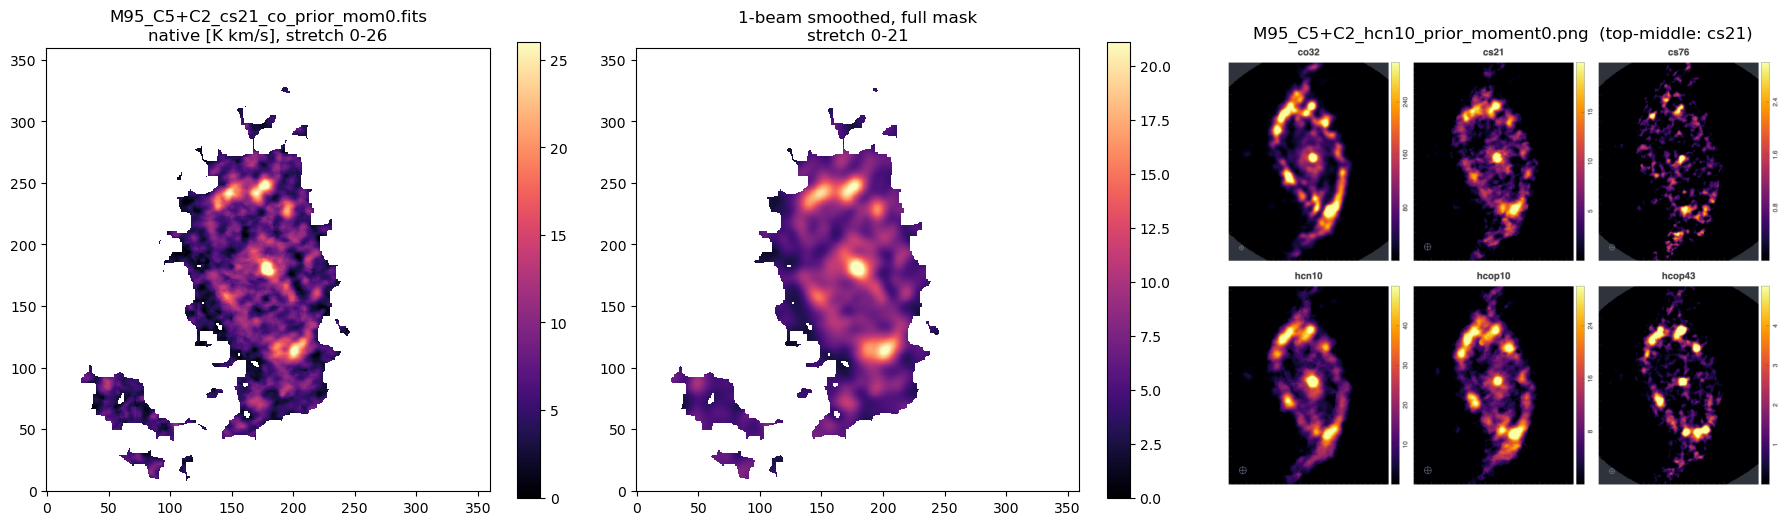

saved M95_C5+C2_cs21_co_prior_mom0_compare.png vmax native=26.0, clipped-sm=21.1


In [14]:
# ---------------------------------------------------------------------------
# 与参考图 M95_C5+C2_hcn10_prior_moment0.png 对比（上排中间即 cs21 面板）
# imshow 自动 vmax 会被亮峰拉高，左/中栏均固定 vmin=0 / vmax=99.5 分位。
# 中栏直接用全 mask footprint 的 1-beam 权重归一平滑产品（_sm1beam）：
# 环内弱发射 mom0 S/N 中位仅 ~0.3，按 S/N>=2 硬裁剪会把环内网状弱发射
# 整片剪黑（与参考图 hcop43 环内紫雾不符），故不再做 S/N 裁剪。
# ---------------------------------------------------------------------------
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from astropy.io import fits

import os
_ref_candidates = ['M95_C5+C2_hcn10_prior_moment0.png',
                   '../M95_C5+C2_hcn10_prior_moment0.png',
                   '../hcn10/M95_C5+C2_hcn10_prior_moment0.png',
                   '../co32/M95_C5+C2_hcn10_prior_moment0.png']
ref_png = next((p for p in _ref_candidates if os.path.exists(p)),
               _ref_candidates[0])
refimg = mpimg.imread(ref_png)
mom0_chk = fits.getdata(outmomt)

_vmax0 = float(np.nanpercentile(mom0_chk, 99.5))

# 全 mask footprint 的 1-beam 权重归一平滑产品（main 中已写出）
_sm = fits.getdata(outmomt.replace('.fits', '_sm1beam.fits'))
_vmax1 = float(np.nanpercentile(_sm, 99.5))

fig, a = plt.subplots(1, 3, figsize=(18, 6))
im0 = a[0].imshow(mom0_chk, origin='lower', cmap='magma', vmin=0, vmax=_vmax0)
a[0].set_title(outmomt + '\nnative [K km/s], stretch 0-%.0f' % _vmax0)
plt.colorbar(im0, ax=a[0], shrink=.8)
im1 = a[1].imshow(_sm, origin='lower', cmap='magma', vmin=0, vmax=_vmax1)
a[1].set_title('1-beam smoothed, full mask\nstretch 0-%.0f' % _vmax1)
plt.colorbar(im1, ax=a[1], shrink=.8)
a[2].imshow(refimg)
a[2].set_title(ref_png + '  (top-middle: cs21)')
a[2].axis('off')
plt.tight_layout()
_outcmp = outmomt.replace('.fits', '_compare.png')
try:
    plt.savefig(_outcmp, dpi=130)
except OSError as _e:
    print('compare png 未写出（可能被图片查看器占用）:', _e)
plt.show()
print('saved', _outcmp, 'vmax native=%.1f, clipped-sm=%.1f' % (_vmax0, _vmax1))


In [15]:
import os; print(outmask, os.path.exists(outmask))


co_mask_on_cs21_grid.fits True


In [16]:
import os; print(outmomt, os.path.exists(outmomt))


M95_C5+C2_cs21_co_prior_mom0.fits True
